R2: 0.8822227868508284
MAE: 16223.200625640407
RMSE: 23537.631013127186


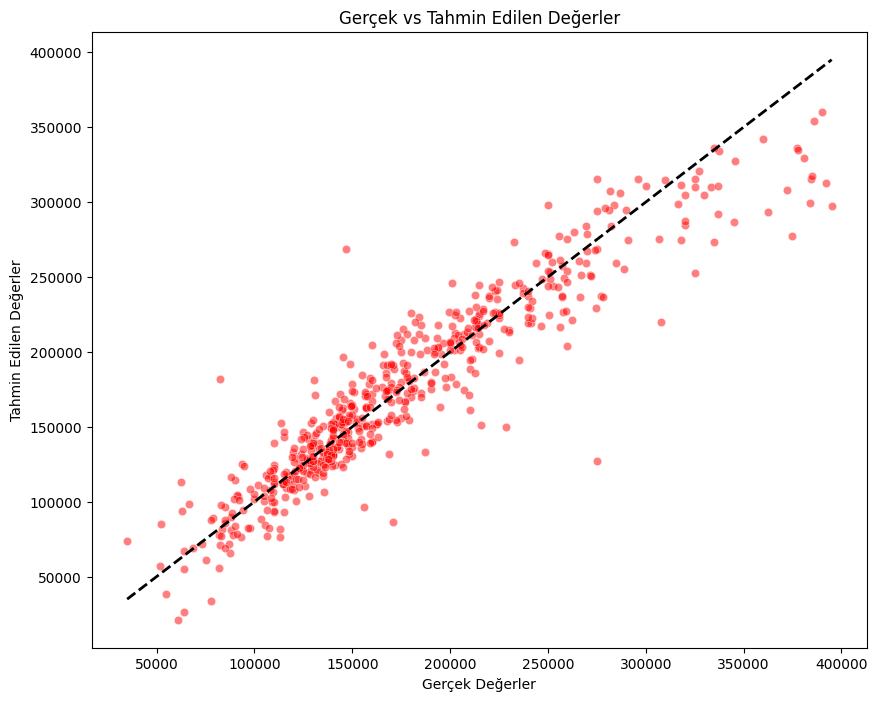

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split


df = pd.read_csv("Ames_Housing_Processed.csv")
df.columns = [col.split('__')[-1] for col in df.columns]


X = df.drop('SalePrice', axis=1)
y = df['SalePrice']


X = X.select_dtypes(include=[np.number])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model_linear = LinearRegression()
model_linear.fit(X_train, y_train)


y_pred = model_linear.predict(X_test)


r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print(f"R2: {r2}")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")


plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='red')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', lw=2, linestyle='--')
plt.xlabel("Actual Sale Prices ($)")
plt.ylabel("Predicted Sale Prices ($)")
plt.title("Actual vs. Predicted Housing Prices (Stacking Ensemble)")
plt.show()
